In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Financial_News_Sentiment_Prediction_using_DeepLearning/cleaned.csv")
df.head()

,text,label,clean_text
0,$BYND - JPMorgan reels in expectations on Beyo...,0,bynd jpmorgan reels expectations beyond meat h...
1,$CCL $RCL - Nomura points to bookings weakness...,0,ccl rcl nomura points bookings weakness carniv...
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0,cx cemex cut credit suisse jp morgan weak buil...
3,$ESS: BTIG Research cuts to Neutral https://t....,0,ess btig research cuts neutral httpstcomcyftsxcn
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0,fnko funko slides piper jaffray pt cut httpstc...


# Visualizations

## Class distribution

In [ ]:
label_names = {
    0: "Bearish",
    1: "Bullish",
    2: "Neutral"
}

df["sentiment"] = df["label"].map(label_names)

df.head()

,text,label,clean_text,sentiment
0,$BYND - JPMorgan reels in expectations on Beyo...,0,bynd jpmorgan reels expectations beyond meat h...,Bearish
1,$CCL $RCL - Nomura points to bookings weakness...,0,ccl rcl nomura points bookings weakness carniv...,Bearish
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0,cx cemex cut credit suisse jp morgan weak buil...,Bearish
3,$ESS: BTIG Research cuts to Neutral https://t....,0,ess btig research cuts neutral httpstcomcyftsxcn,Bearish
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0,fnko funko slides piper jaffray pt cut httpstc...,Bearish


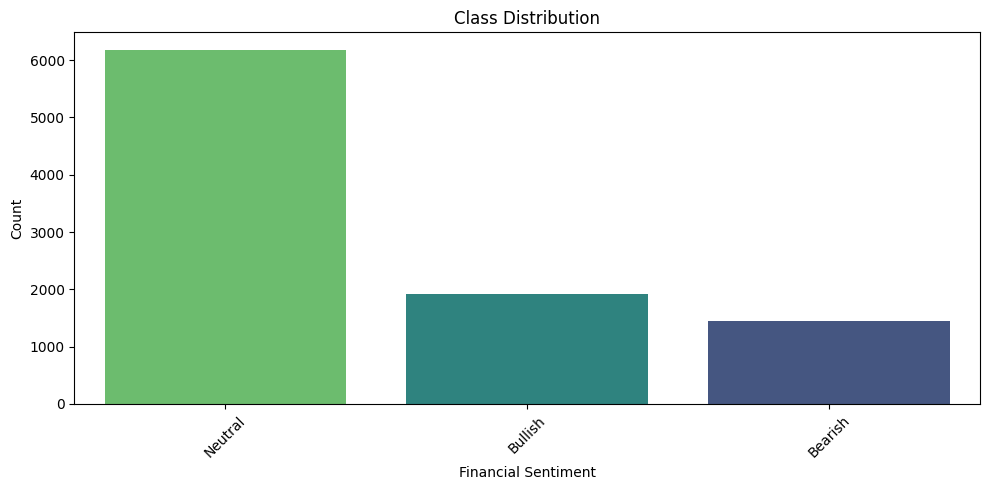

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='sentiment', order=df['sentiment'].value_counts().index,hue = "sentiment", palette='viridis')
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Financial Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Text length distribution (word count per statement)

In [ ]:
print(df['clean_text'].isna().sum())

1


In [ ]:
df['clean_text'] = df['clean_text'].fillna('').astype(str)

In [ ]:
print(df['clean_text'].isna().sum())
print(df['clean_text'].dtype)

0
object


In [ ]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
df

,text,label,clean_text,sentiment,word_count
0,$BYND - JPMorgan reels in expectations on Beyo...,0,bynd jpmorgan reels expectations beyond meat h...,Bearish,7
1,$CCL $RCL - Nomura points to bookings weakness...,0,ccl rcl nomura points bookings weakness carniv...,Bearish,10
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0,cx cemex cut credit suisse jp morgan weak buil...,Bearish,11
3,$ESS: BTIG Research cuts to Neutral https://t....,0,ess btig research cuts neutral httpstcomcyftsxcn,Bearish,6
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0,fnko funko slides piper jaffray pt cut httpstc...,Bearish,8
...,...,...,...,...,...
9538,The Week's Gainers and Losers on the Stoxx Eur...,2,weeks gainers losers stoxx europe dec economy ...,Neutral,10
9539,Tupperware Brands among consumer gainers; Unil...,2,tupperware brands among consumer gainers unile...,Neutral,8
9540,vTv Therapeutics leads healthcare gainers; Myo...,2,vtv therapeutics leads healthcare gainers myom...,Neutral,10
9541,"WORK, XPO, PYX and AMKR among after hour movers",2,work xpo pyx amkr among hour movers,Neutral,7


In [ ]:
df['word_count'].describe()

,word_count
count,9543.000000
mean,8.734570
std,3.063204
min,0.000000
25%,6.000000
50%,8.000000
75%,11.000000
max,27.000000


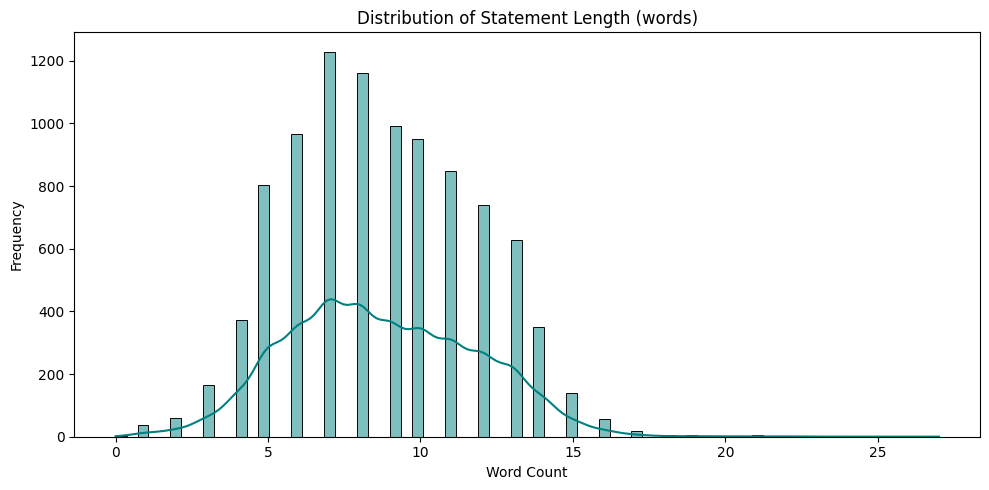

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['word_count'], bins =75, kde=True, color='teal')
plt.title("Distribution of Statement Length (words)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Word cloud — overall vocabulary

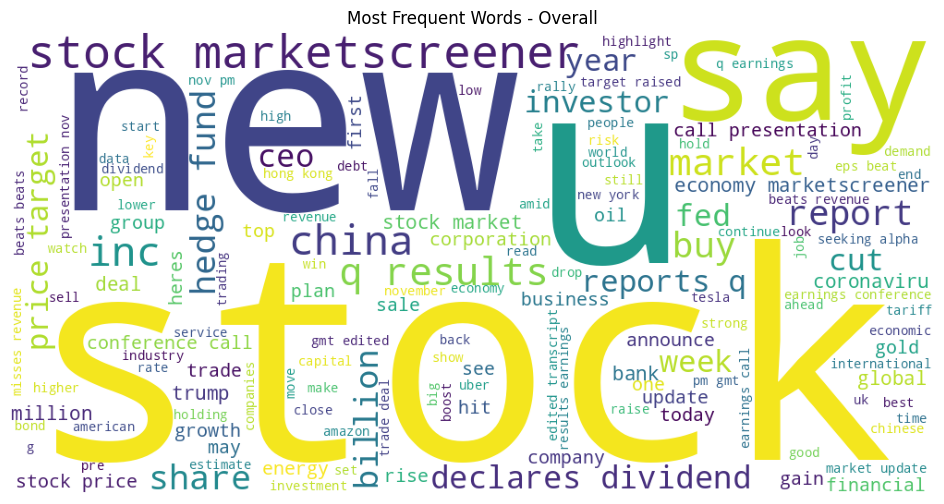

In [ ]:
all_text = " ".join(df['clean_text'])
wc = WordCloud(width=1000, height=500, background_color='white', max_words=150).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis('off')
plt.title("Most Frequent Words - Overall")
plt.show()

In [ ]:
df['sentiment'].unique()

array(['Bearish', 'Bullish', 'Neutral'], dtype=object)

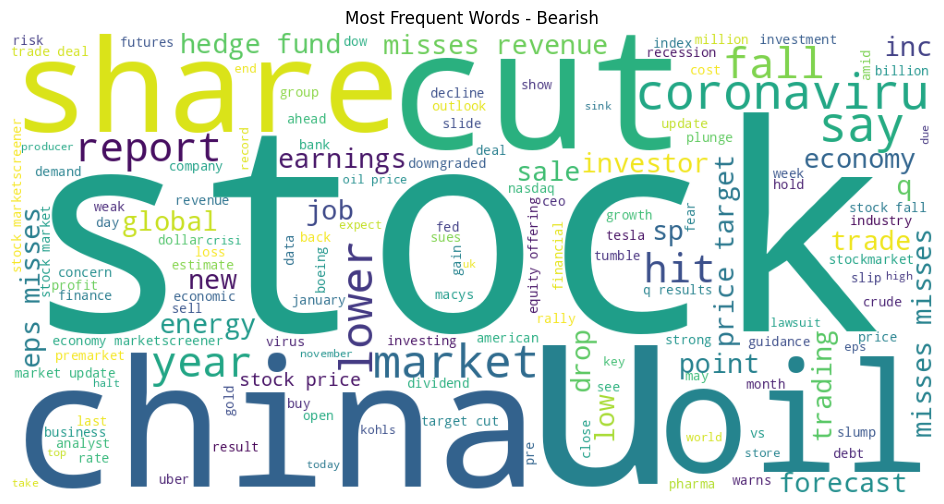

In [ ]:
# Bearish
all_text = " ".join(df[df['sentiment']=='Bearish']['clean_text'])
wc = WordCloud(width=1000, height=500, background_color='white', max_words=150).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis('off')
plt.title("Most Frequent Words - Bearish")
plt.show()

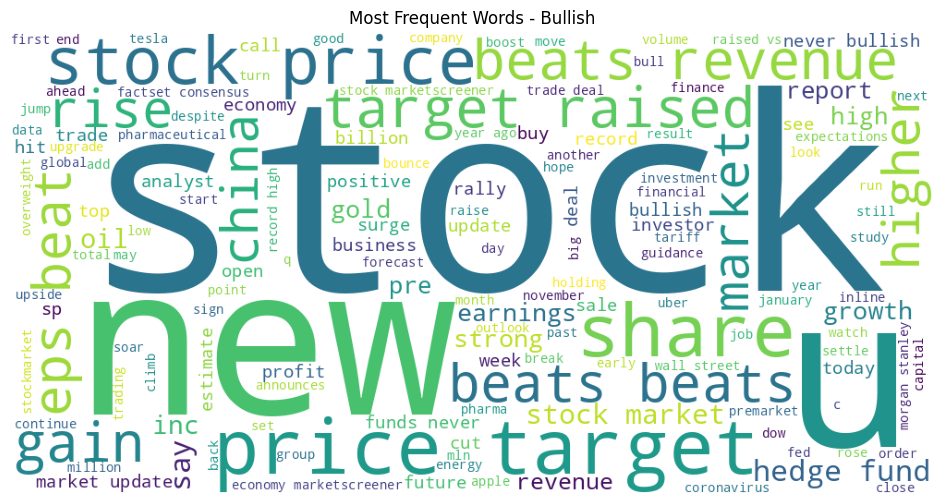

In [ ]:
# Bullish
all_text = " ".join(df[df['sentiment']=='Bullish']['clean_text'])
wc = WordCloud(width=1000, height=500, background_color='white', max_words=150).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis('off')
plt.title("Most Frequent Words - Bullish")
plt.show()

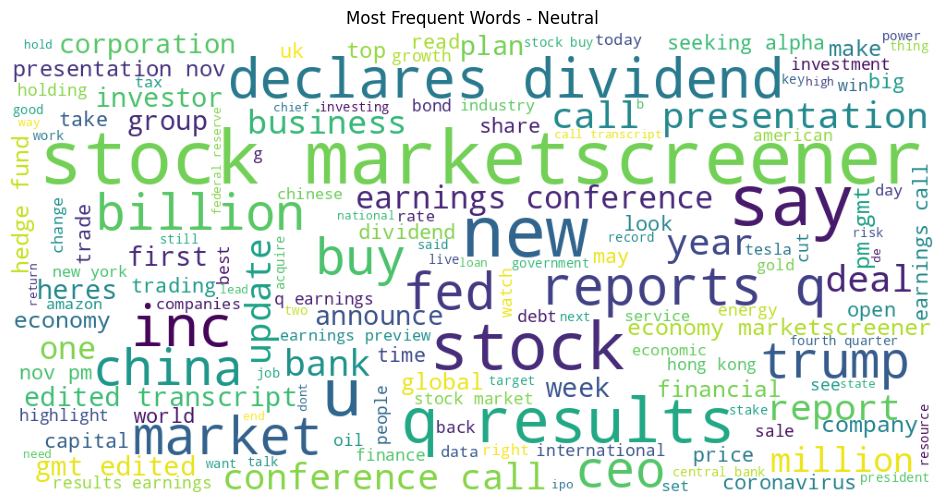

In [ ]:
all_text = " ".join(df[df['sentiment']=='Neutral']['clean_text'])
wc = WordCloud(width=1000, height=500, background_color='white', max_words=150).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis('off')
plt.title("Most Frequent Words - Neutral")
plt.show()